<a href="https://colab.research.google.com/github/Piyush-Sharma-1/Diffusion_from_Scratch/blob/main/mnist_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
#Load MNIST
# MNIST: 28×28 grayscale digits, values in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),  # converts PIL image → tensor, scales to [0, 1]
])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [128, 1, 28, 28]
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


Batch shape: torch.Size([128, 1, 28, 28])
Pixel range: [0.00, 1.00]


In [3]:
#Conv VAE Model
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=20, hidden_dims=None, kernel_size=3):
        """
        Args:
            latent_dim: size of the latent code z        # [PLAY]
            hidden_dims: list of channel sizes per layer # [PLAY] try [16,32,64] or [64,128,256]
            kernel_size: size of conv filters            # [PLAY] try 5
        """
        super().__init__()
        self.latent_dim = latent_dim
        if hidden_dims is None:
            hidden_dims = [32, 64, 128]  # [PLAY] ← change these three numbers!

        # ---- Encoder: 1×28×28 → latent distribution ----
        # Build encoder dynamically from hidden_dims list
        encoder_layers = []
        in_ch = 1
        for i, out_ch in enumerate(hidden_dims):
            # Last conv layer uses padding=0; others use padding=1
            pad = 0 if i == len(hidden_dims) - 1 else 1
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=2, padding=pad),
                nn.ReLU(),
            ])
            in_ch = out_ch
        encoder_layers.append(nn.Flatten())
        self.encoder = nn.Sequential(*encoder_layers)

        # Compute flattened size dynamically
        # After stride=2 three times: 28/2=14, 14/2=7, 7/2=3 (floor)
        # Last conv: kernel=3, stride=2, pad=0 on 7×7 → ceil((7-3+1)/2) = 3
        self.flattened_size = hidden_dims[-1] * 3 * 3
        self.last_channel   = hidden_dims[-1]  # for reshape in decode

        self.fc_mu    = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # ---- Decoder: latent → 1×28×28 ----
        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)

        # Build decoder dynamically from reversed hidden_dims
        decoder_layers = []
        rev_dims = list(reversed(hidden_dims))
        for i in range(len(rev_dims) - 1):
            decoder_layers.extend([
                nn.ConvTranspose2d(rev_dims[i], rev_dims[i+1],
                                   kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
            ])
        # Final layer: rev_dims[-1] → 1
        decoder_layers.extend([
            nn.ConvTranspose2d(rev_dims[-1], 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),  # output in [0, 1] to match input
        ])
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """x: [B, 1, 28, 28] → mu: [B, latent_dim], logvar: [B, latent_dim]"""
        h = self.encoder(x)           # [B, flattened_size]
        mu = self.fc_mu(h)            # [B, latent_dim]
        logvar = self.fc_logvar(h)    # [B, latent_dim]
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Sample z = μ + σ · ε  (same trick as Week 3)"""
        std = torch.exp(0.5 * logvar)         # σ = exp(0.5 · log(σ²))
        eps = torch.randn_like(std)           # ε ~ N(0, I)
        return mu + eps * std

    def decode(self, z):
        """z: [B, latent_dim] → reconstruction: [B, 1, 24, 24]"""
        h = self.decoder_input(z)             # [B, flattened_size]
        h = h.view(-1, self.last_channel, 3, 3)   # reshape to [B, C_last, 3, 3]
        return self.decoder(h)                # [B, 1, 24, 24]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [4]:
#Loss Function
def vae_loss(recon, x, mu, logvar, beta=1.0):
    """
    recon:  [B, 1, 24, 24] -- decoder output
    x:      [B, 1, 28, 28] -- original image
    mu, logvar: [B, latent_dim]

    Returns: total_loss, recon_loss, kl_loss
    """
    # Resize reconstruction to match input size
    recon_resized = F.interpolate(recon, size=(28, 28), mode='bilinear')

    # Reconstruction: Binary Cross-Entropy (per-pixel)
    # We use reduction='sum' to match the KL term (also summed over latent dims)
    BCE = F.binary_cross_entropy(
        recon_resized, x, reduction='sum'
    )

    # KL Divergence: closed form (same as Week 2 & 3)
    # KL = -0.5 * sum(1 + log(σ²) - μ² - σ²)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total = BCE + beta * KLD
    return total, BCE, KLD

In [5]:
#Training Loop
def train_epoch(model, loader, optimizer, beta=1.0):
    model.train()
    total_loss, total_bce, total_kld = 0, 0, 0

    for x, _ in loader:  # we don't use labels
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, bce, kld = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce  += bce.item()
        total_kld  += kld.item()

    n = len(loader.dataset)
    return total_loss / n, total_bce / n, total_kld / n


def evaluate(model, loader, beta=1.0):
    model.eval()
    total_loss, total_bce, total_kld = 0, 0, 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, bce, kld = vae_loss(recon, x, mu, logvar, beta=beta)
            total_loss += loss.item()
            total_bce  += bce.item()
            total_kld  += kld.item()

    n = len(loader.dataset)
    return total_loss / n, total_bce / n, total_kld / n

In [6]:
#Run Training
# ===== CONFIGURATION -- change these! =====
LATENT_DIM  = 20       # [PLAY] size of latent code z
LEARNING_RATE = 1e-3   # [PLAY] try 5e-4 or 3e-3
EPOCHS      = 30       # [PLAY] try 10, 50, 100
BETA        = 1.0      # [PLAY] KL weight -- try 0.1, 0.5, 2.0
# ==========================================

model = ConvVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

epochs = EPOCHS
history = {
    "train_loss": [], "train_bce": [], "train_kld": [],
    "test_loss":  [], "test_bce":  [], "test_kld":  []
}

# The header print statement
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train BCE':>12} {'Train KLD':>12} "
      f"{'Test Loss':>12} {'Test BCE':>12} {'Test KLD':>12}")
print("-" * 78)

for epoch in range(1, epochs + 1):
    train_l, train_b, train_k = train_epoch(model, train_loader, optimizer, beta=BETA)
    test_l,  test_b,  test_k  = evaluate(model, test_loader, beta=BETA)

    history["train_loss"].append(train_l)
    history["train_bce"].append(train_b)
    history["train_kld"].append(train_k)
    history["test_loss"].append(test_l)
    history["test_bce"].append(test_b)
    history["test_kld"].append(test_k)

    # The loop print statement
    print(f"{epoch:>6} {train_l:>12.2f} {train_b:>12.2f} {train_k:>12.2f} "
          f"{test_l:>12.2f} {test_b:>12.2f} {test_k:>12.2f}")

 Epoch   Train Loss    Train BCE    Train KLD    Test Loss     Test BCE     Test KLD
------------------------------------------------------------------------------
     1       177.92       164.44        13.48       118.96        98.20        20.77
     2       113.56        91.06        22.50       109.29        86.06        23.23
     3       108.66        85.46        23.19       107.00        83.72        23.28
     4       106.72        83.40        23.32       105.67        81.83        23.84
     5       105.59        82.28        23.31       104.44        81.64        22.80
     6       104.75        81.51        23.25       104.13        81.48        22.65
     7       104.10        80.91        23.19       103.54        80.25        23.29
     8       103.59        80.44        23.15       102.90        79.37        23.53
     9       103.20        80.12        23.08       102.71        79.39        23.31
    10       102.81        79.72        23.09       102.43        79.95

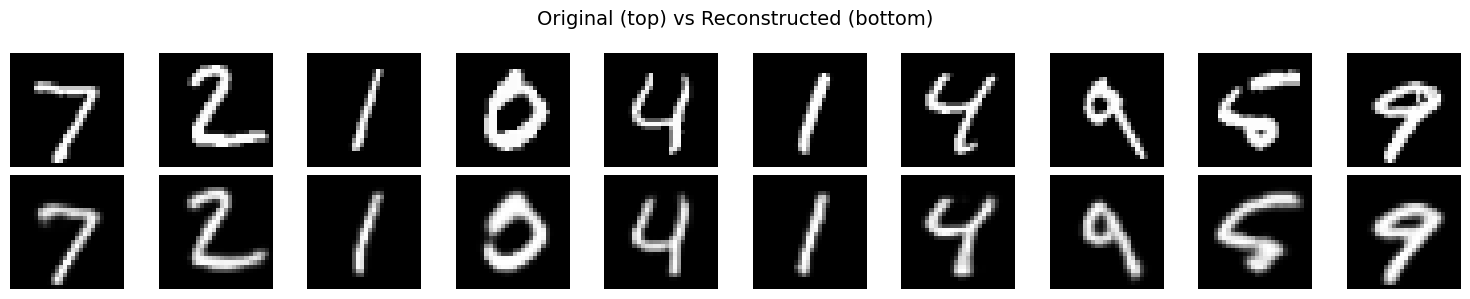

In [7]:
# Reconstructions: Side-by-Side
@torch.no_grad()
def show_reconstructions(model, loader, n=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)

    recon, _, _ = model(x)
    recon = F.interpolate(recon, size=(28, 28), mode='bilinear')

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i, 0].cpu(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=10)

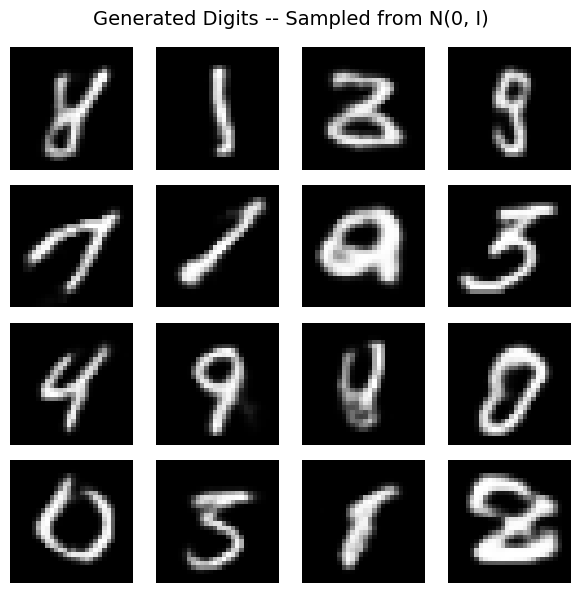

In [8]:
#Generated Digits: Sample From Prior
@torch.no_grad()
def generate_digits(model, n=16, latent_dim=20):
    model.eval()
    # Sample z from the prior: N(0, I)
    z = torch.randn(n, latent_dim).to(device)
    samples = model.decode(z)
    samples = F.interpolate(samples, size=(28, 28), mode='bilinear')

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0].cpu(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Generated Digits -- Sampled from N(0, I)", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_digits(model, n=16)

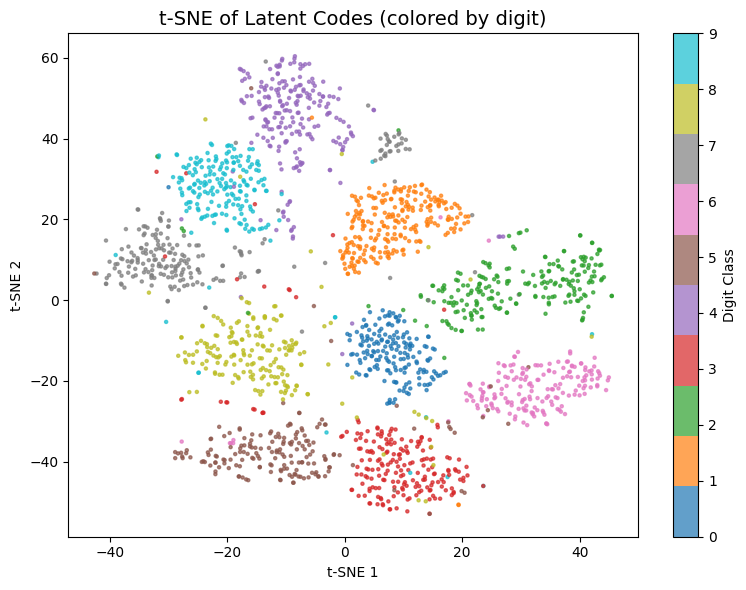

In [9]:
#Latent Space: t-SNE Visualization
from sklearn.manifold import TSNE

@torch.no_grad()
def plot_latent_tsne(model, loader, n_samples=2000):
    model.eval()
    all_z = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        mu, _ = model.encode(x)
        all_z.append(mu.cpu())
        all_labels.append(y)
        if len(torch.cat(all_z)) >= n_samples:
            break

    z = torch.cat(all_z)[:n_samples].numpy()
    labels = torch.cat(all_labels)[:n_samples].numpy()

    # t-SNE to 2D
    z_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(z)

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10',
                         s=5, alpha=0.7)
    plt.colorbar(scatter, label="Digit Class")
    ax.set_title("t-SNE of Latent Codes (colored by digit)", fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

plot_latent_tsne(model, test_loader)

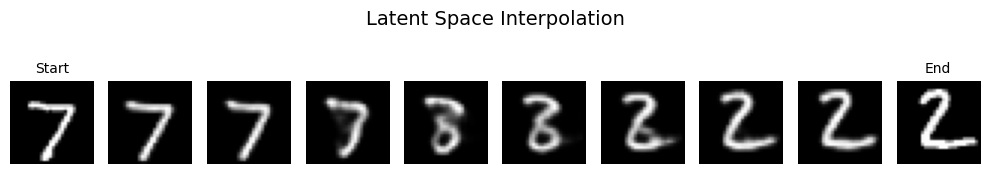

In [10]:
#Latent Space Interpolation
@torch.no_grad()
def interpolate(model, loader, latent_dim=20, steps=8):
    model.eval()
    x, _ = next(iter(loader))

    # Take two real images
    img1 = x[0:1].to(device)
    img2 = x[1:2].to(device)

    # Get their latent codes
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

    # Interpolate
    alphas = torch.linspace(0, 1, steps).to(device)
    interpolations = []
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z_interp)
        recon = F.interpolate(recon, size=(28, 28), mode='bilinear')
        interpolations.append(recon)

    # Plot
    fig, axes = plt.subplots(1, steps + 2, figsize=(steps + 2, 2))
    axes[0].imshow(img1[0, 0].cpu(), cmap='gray')
    axes[0].set_title("Start", fontsize=10)
    axes[0].axis('off')

    for i, recon in enumerate(interpolations):
        axes[i+1].imshow(recon[0, 0].cpu(), cmap='gray')
        axes[i+1].axis('off')

    axes[-1].imshow(img2[0, 0].cpu(), cmap='gray')
    axes[-1].set_title("End", fontsize=10)
    axes[-1].axis('off')

    plt.suptitle("Latent Space Interpolation", fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate(model, test_loader, steps=8)

In [20]:
# Part 3: Beta knob
betas = [0.0, 0.5, 2.0]
trained_models = {}
beta_histories = {}

for beta in betas:
    print(f"\n=============================================")
    print(f"         Training with β = {beta}")
    print(f"=============================================")
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Train BCE':>12} {'Train KLD':>12}")
    print("-" * 45)

    model_b = ConvVAE(latent_dim=20).to(device)
    opt_b   = optim.Adam(model_b.parameters(), lr=1e-3)

    current_loss_history = []

    for epoch in range(1, 31):
        train_l, train_b, train_k = train_epoch(model_b, train_loader, opt_b, beta=beta)
        current_loss_history.append(train_l)
        print(f"{epoch:>6} {train_l:>12.2f} {train_b:>12.2f} {train_k:>12.2f}")

    trained_models[beta] = model_b
    beta_histories[beta] = current_loss_history


         Training with β = 0.0
 Epoch   Train Loss    Train BCE    Train KLD
---------------------------------------------
     1       144.85       144.85       597.27
     2        78.42        78.42       888.56
     3        73.44        73.44       783.15
     4        71.61        71.61       688.71
     5        70.53        70.53       614.06
     6        69.83        69.83       553.93
     7        69.29        69.29       502.93
     8        68.83        68.83       468.41
     9        68.53        68.53       435.01
    10        68.21        68.21       407.32
    11        67.97        67.97       384.52
    12        67.76        67.76       365.79
    13        67.55        67.55       349.16
    14        67.39        67.39       329.37
    15        67.23        67.23       317.46
    16        67.07        67.07       307.34
    17        66.93        66.93       294.09
    18        66.80        66.80       286.89
    19        66.71        66.71       277.84
  


         Visualizations for β = 0.0

[β=0.0] Reconstructions:


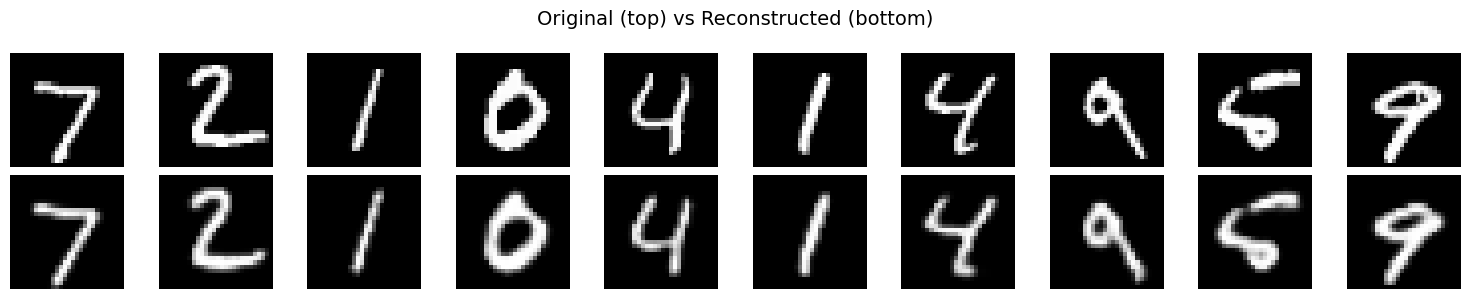


[β=0.0] Generated Samples:


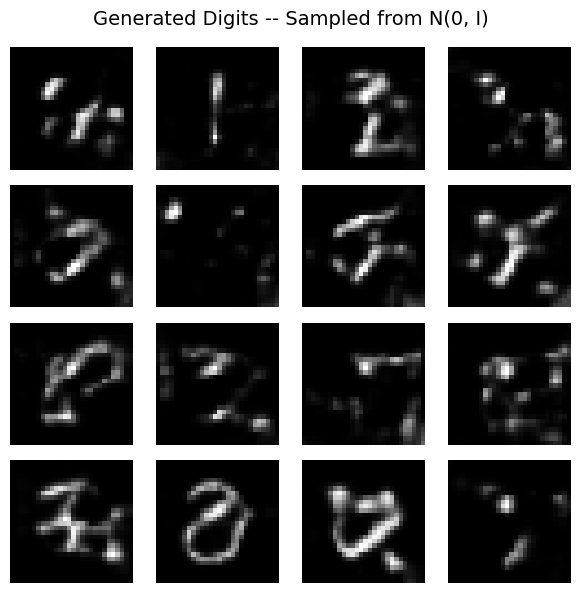


         Visualizations for β = 0.5

[β=0.5] Reconstructions:


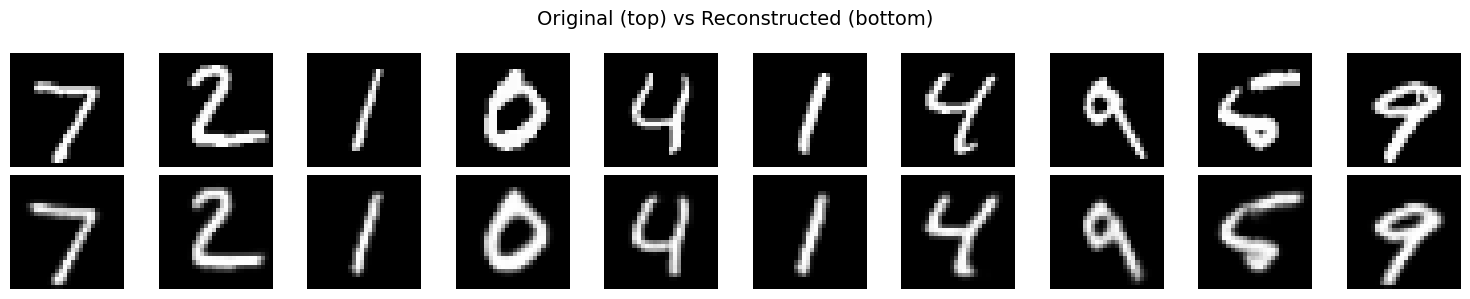


[β=0.5] Generated Samples:


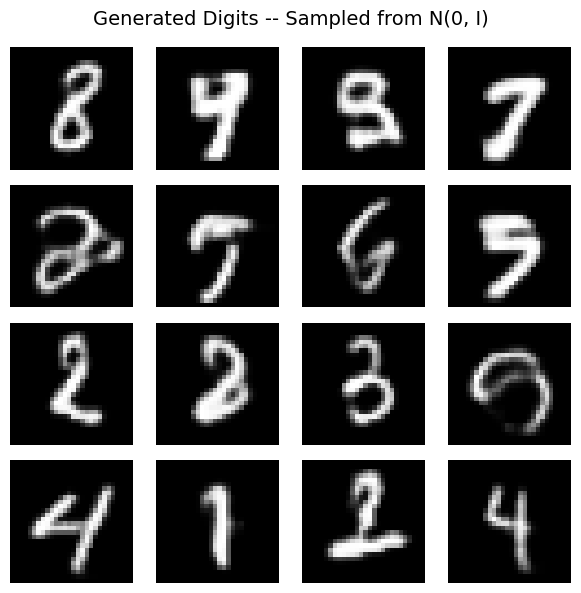


         Visualizations for β = 2.0

[β=2.0] Reconstructions:


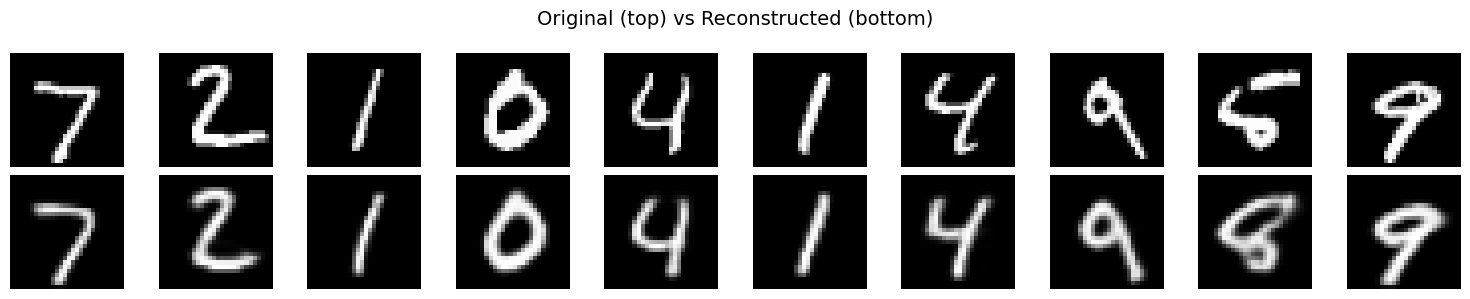


[β=2.0] Generated Samples:


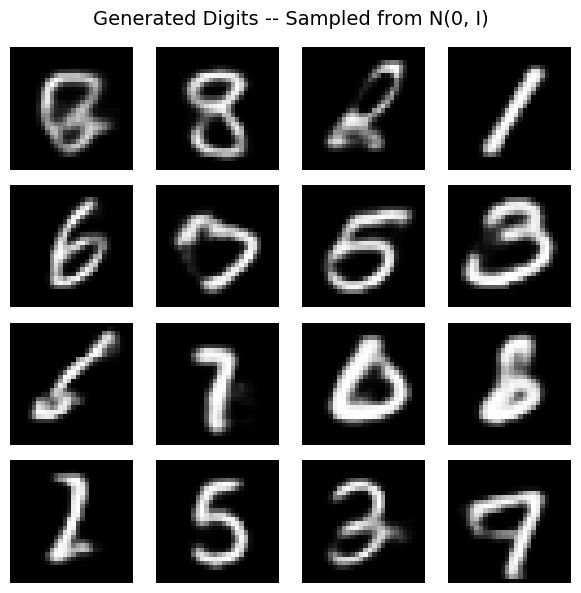

In [21]:
# Part 3: Beta Experiment - Visualizations
for beta, model_b in trained_models.items():
    print(f"\n" + "="*45)
    print(f"         Visualizations for β = {beta}")
    print("="*45)

    # 1. Show Reconstructions (Original vs Reconstructed)
    print(f"\n[β={beta}] Reconstructions:")
    show_reconstructions(model_b, test_loader, n=10)

    # 2. Generate 16 new samples from random noise
    print(f"\n[β={beta}] Generated Samples:")
    generate_digits(model_b, n=16)

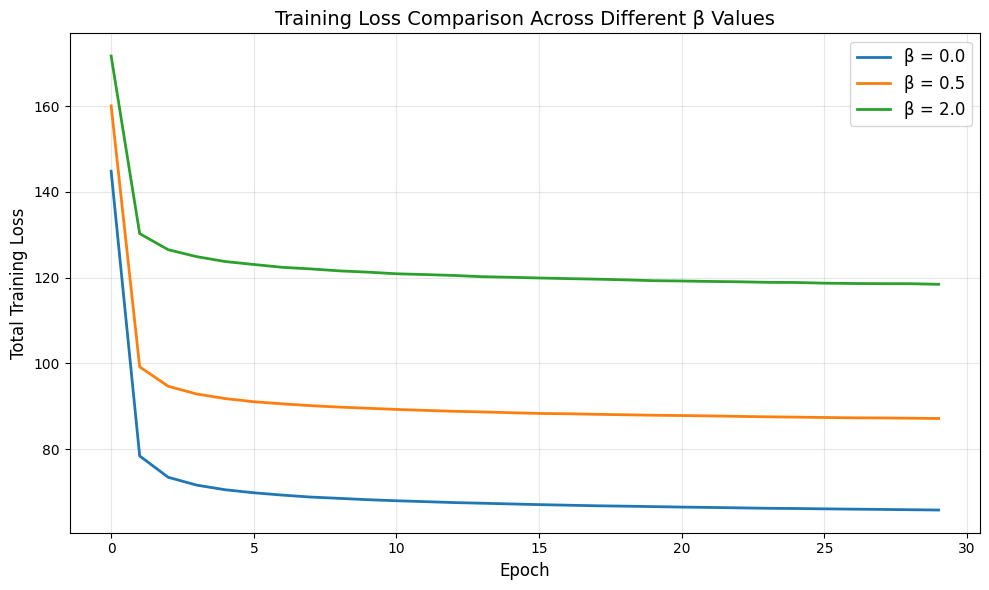

In [22]:
# Plot: Training Loss Comparison Across Beta Values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for beta, losses in beta_histories.items():
    plt.plot(losses, label=f"β = {beta}", linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Total Training Loss", fontsize=12)
plt.title("Training Loss Comparison Across Different β Values", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Part 3: What changes as β increases, and why?
As β increases, the reconstructed images often become blurrier, but the model generates much more coherent and realistic samples from random noise. This happens because a higher β places a stronger penalty on the KL divergence, forcing the model to prioritize a smooth, well-organized latent space over perfectly memorizing exact pixel reconstructions.


         Training with KL Annealing
 Epoch   Beta   Train Loss    Train BCE    Train KLD
-------------------------------------------------------
     1   0.10       153.68       149.53        41.54
     2   0.20        89.71        80.75        44.80
     3   0.30        88.92        76.95        39.91
     4   0.40        90.82        76.34        36.18
     5   0.50        93.03        76.42        33.24
     6   0.60        95.47        76.93        30.90
     7   0.70        97.79        77.56        28.91
     8   0.80       100.08        78.30        27.23
     9   0.90       102.23        79.10        25.70
    10   1.00       104.29        79.92        24.37
    11   1.00       103.78        79.71        24.07
    12   1.00       103.40        79.52        23.88
    13   1.00       103.11        79.36        23.75
    14   1.00       102.72        79.12        23.60
    15   1.00       102.50        79.01        23.50
    16   1.00       102.22        78.85        23.37
    17

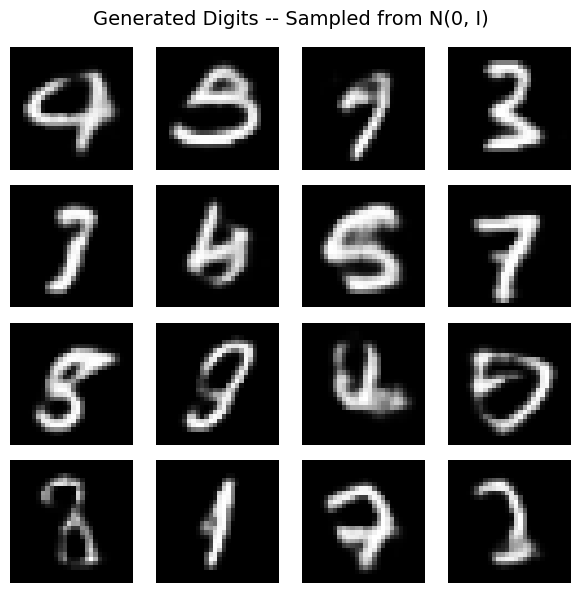

In [13]:
# Bonus: KL Annealing Experiment
print(f"\n=============================================")
print(f"         Training with KL Annealing")
print(f"=============================================")
print(f"{'Epoch':>6} {'Beta':>6} {'Train Loss':>12} {'Train BCE':>12} {'Train KLD':>12}")
print("-" * 55)

# Initialize a fresh model and optimizer
model_anneal = ConvVAE(latent_dim=20).to(device)
optimizer_anneal = optim.Adam(model_anneal.parameters(), lr=1e-3)

epochs_total = 30
anneal_duration = 10

for epoch in range(1, epochs_total + 1):
    # Linearly increase β from 0 to 1 over the first 10 epochs
    current_beta = min(1.0, epoch / anneal_duration)

    # Train for one epoch
    train_l, train_b, train_k = train_epoch(model_anneal, train_loader, optimizer_anneal, beta=current_beta)

    # Print the values in our clean table format (Single braces!)
    print(f"{epoch:>6} {current_beta:>6.2f} {train_l:>12.2f} {train_b:>12.2f} {train_k:>12.2f}")

# Generate 16 samples after training is complete
print(f"\nKL Annealing: Generated Samples")
generate_digits(model_anneal, n=16)

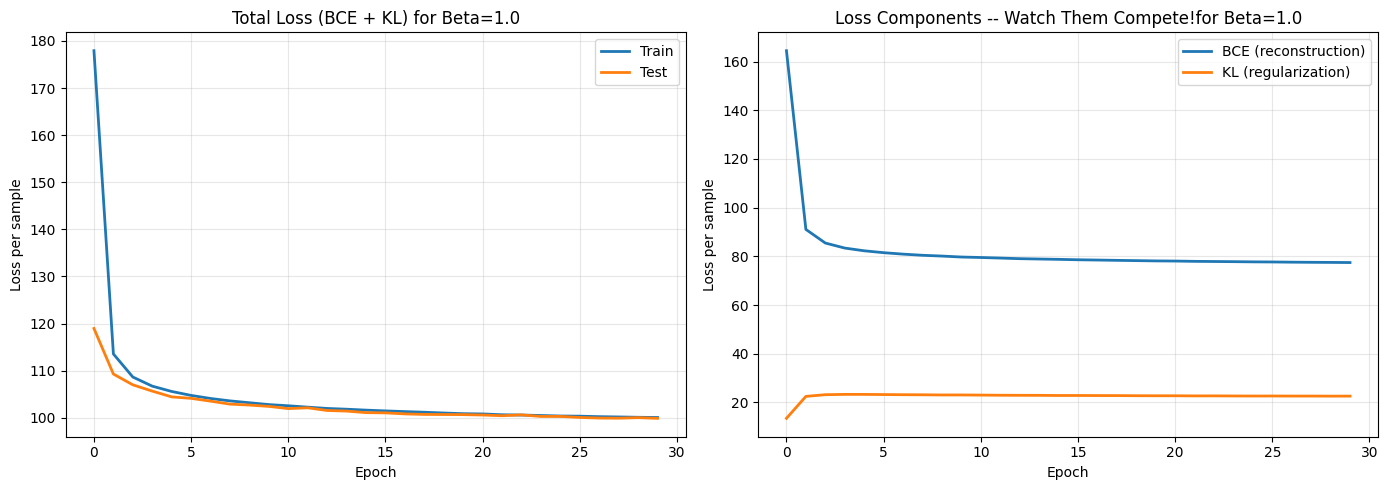

In [19]:
#Loss Curves
def plot_losses(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Total loss
    axes[0].plot(history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(history["test_loss"],  label="Test",  linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss per sample")
    axes[0].set_title("Total Loss (BCE + KL) for Beta=1.0")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # BCE vs KL
    axes[1].plot(history["train_bce"], label="BCE (reconstruction)", linewidth=2)
    axes[1].plot(history["train_kld"], label="KL (regularization)", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss per sample")
    axes[1].set_title("Loss Components -- Watch Them Compete!for Beta=1.0")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_losses(history)

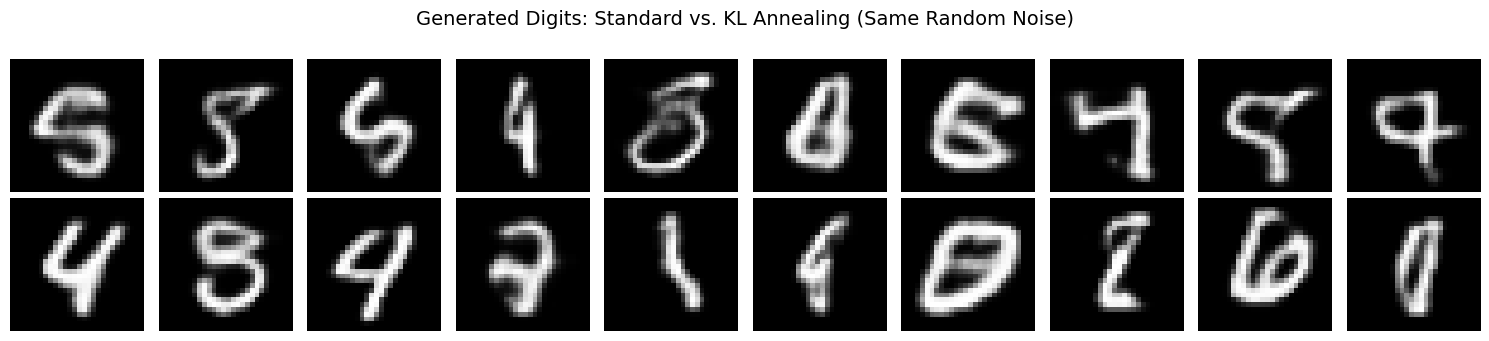

In [18]:
# Visual Comparison: Standard vs. KL Annealing
@torch.no_grad()
def compare_models(model_standard, model_annealed, n=10, latent_dim=20):
    model_standard.eval()
    model_annealed.eval()

    # We use the exact same random latent vectors for a 1-to-1 fair comparison
    z = torch.randn(n, latent_dim).to(device)

    samples_standard = model_standard.decode(z)
    samples_standard = F.interpolate(samples_standard, size=(28, 28), mode='bilinear')

    samples_annealed = model_annealed.decode(z)
    samples_annealed = F.interpolate(samples_annealed, size=(28, 28), mode='bilinear')

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3.5))

    for i in range(n):
        # Top Row: Standard Beta=1.0 model
        axes[0, i].imshow(samples_standard[i, 0].cpu(), cmap='gray')
        axes[0, i].axis('off')

        # Bottom Row: KL Annealing model
        axes[1, i].imshow(samples_annealed[i, 0].cpu(), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Standard (β=1.0)", fontsize=12)
    axes[1, 0].set_ylabel("KL Annealing", fontsize=12)

    plt.suptitle("Generated Digits: Standard vs. KL Annealing (Same Random Noise)", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run the comparison using your original 'model' and your new 'model_anneal'
compare_models(model, model_anneal, n=10)